In [23]:
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from time import time
 
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    f1_score, balanced_accuracy_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
 
import joblib
warnings.filterwarnings("ignore")
 
RANDOM_STATE = 42
TARGET       = "next_day_risk_class"
DATA_DIR     = Path("../data/engineered")
MODEL_Comp_DIR    = Path("../data/model_comparison") 
MODEL_Comp_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR      = Path("outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)
 
RISK_LABELS = {0:"LOW", 1:"MODERATE", 2:"HIGH"}
RISK_COLORS = {0:"#2ecc71", 1:"#f39c12", 2:"#e74c3c"}
 
with open(DATA_DIR/"feature_meta.json") as f:
    meta = json.load(f)

FEATURES = meta["final_features"]
ID_COLS  = meta["id_cols"]

print(f"Features: {len(FEATURES)}")
print(f"Train: {meta['train_years']}  Val: {meta['validation_years']}  "
      f"Test: {meta['test_years']}  Stress: {meta['stress_years']}")

Features: 37
Train: [2015, 2016, 2017, 2018]  Val: [2019]  Test: [2021, 2022, 2023, 2024, 2025]  Stress: [2020]


### Load Splits and Define Class Weights

- Load the train, validation, test, and 2020 stress-test splits.
- Separate each split into input features (`X`) and the target (`y`).
- Verify the size and positive-risk rate of each split.
- Compute balanced class weights using the **training data only**.
- Give higher weights to minority classes, especially the **HIGH-risk class**, to penalize missed high-risk events more strongly.
- Generate sample weights for use during model training.

In [17]:
# Load splits
train     = pd.read_parquet(DATA_DIR/"train.parquet")
val       = pd.read_parquet(DATA_DIR/"val.parquet")
test      = pd.read_parquet(DATA_DIR/"test.parquet")
stress_20 = pd.read_parquet(DATA_DIR/"stress_2020.parquet")
 
X_train, y_train = train[FEATURES],     train[TARGET]
X_val,   y_val   = val[FEATURES],       val[TARGET]
X_test,  y_test  = test[FEATURES],      test[TARGET]
X_stress, y_stress = stress_20[FEATURES], stress_20[TARGET]
 
for name, X, y in [("TRAIN",X_train,y_train),("VAL",X_val,y_val),
                    ("TEST",X_test,y_test),("STRESS-2020",X_stress,y_stress)]:
    pos = 100*(y>0).mean()
    print(f"{name:<12} {X.shape}  positive={pos:.1f}%")
 
# Class weights 
from sklearn.utils.class_weight import compute_class_weight
cw = compute_class_weight("balanced", classes=np.array([0,1,2]), y=y_train)
CLASS_WEIGHTS = {0:cw[0], 1:cw[1], 2:cw[2]}
SAMPLE_WEIGHTS = y_train.map(CLASS_WEIGHTS).values
 
print(f"\nClass weights (balanced): {CLASS_WEIGHTS}")
print(f"HIGH weight = {CLASS_WEIGHTS[2]:.2f}x more than LOW")

TRAIN        (54890, 37)  positive=19.3%
VAL          (15938, 37)  positive=27.7%
TEST         (68657, 37)  positive=15.6%
STRESS-2020  (16995, 37)  positive=32.7%

Class weights (balanced): {0: np.float64(0.413063927456071), 1: np.float64(2.219930437596053), 2: np.float64(7.77588893610993)}
HIGH weight = 7.78x more than LOW


### Evaluation Helpers

- Define reusable functions to evaluate model performance on different data splits.
- `evaluate()` computes:
  - Classification report
  - Macro F1 and weighted F1
  - Balanced accuracy
  - Macro one-vs-rest AUC
  - Per-class F1 scores for LOW, MODERATE, and HIGH
- `plot_cm()` generates both raw and normalized confusion matrices to analyze prediction errors and recall for each risk class.
- Save evaluation plots for later comparison between models.

In [18]:
def evaluate(name, model, X, y, split="val"):
    preds = model.predict(X)
    proba = model.predict_proba(X) if hasattr(model,"predict_proba") else None
    auc = roc_auc_score(y, proba, multi_class="ovr", average="macro") if proba is not None else float("nan")
    macro_f1    = f1_score(y, preds, average="macro",    zero_division=0)
    weighted_f1 = f1_score(y, preds, average="weighted", zero_division=0)
    bal_acc     = balanced_accuracy_score(y, preds)
    per_class   = f1_score(y, preds, average=None,       zero_division=0)
 
    print(f"\n{'─'*60}")
    print(f"{name}  [{split}]")
    print(f"{'─'*60}")
    print(classification_report(y, preds,
          target_names=[RISK_LABELS[i] for i in range(3)], zero_division=0))
    print(f"Macro F1:         {macro_f1:.4f}")
    print(f"Balanced Acc:     {bal_acc:.4f}")
    print(f"AUC (OvR macro):  {auc:.4f}")
    return {
        "model":name, "split":split,
        "macro_f1":    round(macro_f1,4),
        "balanced_acc":round(bal_acc,4),
        "auc_ovr":     round(auc,4),
        "weighted_f1": round(weighted_f1,4),
        "f1_LOW":      round(per_class[0],4),
        "f1_MODERATE": round(per_class[1],4),
        "f1_HIGH":     round(per_class[2],4),
    }
 
def plot_cm(name, model, X, y, fname):
    preds = model.predict(X)
    cm = confusion_matrix(y, preds)
    fig, axes = plt.subplots(1,2,figsize=(14,5))
    ConfusionMatrixDisplay(cm, display_labels=[RISK_LABELS[i] for i in range(3)]).plot(
        ax=axes[0], colorbar=False, cmap="Blues")
    axes[0].set_title(f"{name} — counts")
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    ConfusionMatrixDisplay(cm_norm.round(2), display_labels=[RISK_LABELS[i] for i in range(3)]).plot(
        ax=axes[1], colorbar=False, cmap="Blues")
    axes[1].set_title(f"{name} — recall per class")
    plt.tight_layout()
    plt.savefig(OUT_DIR/fname, dpi=150, bbox_inches="tight")
    plt.show()

### Majority Class Baseline

- Establish a simple baseline by always predicting the **most frequent class** in the training data.
- Evaluate this baseline on the validation set using the same metrics as the ML models.
- Use its Macro F1 as a minimum reference point for model performance.
- Every trained model should **significantly outperform this baseline** to demonstrate that it is learning meaningful wildfire-risk patterns.

In [19]:
class MajorityClassifier:
    def fit(self, X, y): self.maj = y.value_counts().idxmax(); return self
    def predict(self, X): return np.full(len(X), self.maj)
    def predict_proba(self, X):
        p = np.zeros((len(X),3)); p[:,self.maj]=1.0; return p
 
baseline = MajorityClassifier().fit(X_train, y_train)
results = [evaluate("Majority Baseline", baseline, X_val, y_val)]
print(f"\nBaseline macro F1: {results[0]['macro_f1']:.4f}")


────────────────────────────────────────────────────────────
Majority Baseline  [val]
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

         LOW       0.72      1.00      0.84     11527
    MODERATE       0.00      0.00      0.00      3169
        HIGH       0.00      0.00      0.00      1242

    accuracy                           0.72     15938
   macro avg       0.24      0.33      0.28     15938
weighted avg       0.52      0.72      0.61     15938

Macro F1:         0.2798
Balanced Acc:     0.3333
AUC (OvR macro):  0.5000

Baseline macro F1: 0.2798


### Logistic Regression — Linear Baseline

- Train a **Logistic Regression** model as a simple linear baseline.
- Standardize the features because Logistic Regression is sensitive to feature scale.
- Use `class_weight="balanced"` to account for the imbalanced risk classes.

In [20]:
print("Training Logistic Regression...")
lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        max_iter=1000, class_weight="balanced",
        C=0.1, random_state=RANDOM_STATE, n_jobs=-1
    ))
])
t0 = time()
lr_pipe.fit(X_train.fillna(0), y_train)
print(f"Trained in {time()-t0:.1f}s")
results.append(evaluate("Logistic Regression", lr_pipe, X_val.fillna(0), y_val))

Training Logistic Regression...
Trained in 2.6s

────────────────────────────────────────────────────────────
Logistic Regression  [val]
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

         LOW       0.86      0.77      0.81     11527
    MODERATE       0.37      0.39      0.38      3169
        HIGH       0.31      0.55      0.39      1242

    accuracy                           0.68     15938
   macro avg       0.51      0.57      0.53     15938
weighted avg       0.72      0.68      0.70     15938

Macro F1:         0.5298
Balanced Acc:     0.5711
AUC (OvR macro):  0.7808


### Random Forest

- Train a **Random Forest** to capture nonlinear relationships and feature interactions that Logistic Regression cannot model.
- Use `n_estimators=500` to obtain more stable predictions across trees.
- Allow trees to grow without a fixed depth limit while using `min_samples_leaf=10` to reduce overfitting.
- Use `max_features="sqrt"` to introduce diversity between trees.
- Apply `class_weight="balanced_subsample"` to handle class imbalance separately within each bootstrap sample.

In [21]:
print("Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=10,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
t0 = time()
rf.fit(X_train.fillna(0), y_train)
print(f"Trained in {time()-t0:.1f}s")
results.append(evaluate("Random Forest", rf, X_val.fillna(0), y_val))

Training Random Forest...
Trained in 17.4s

────────────────────────────────────────────────────────────
Random Forest  [val]
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

         LOW       0.85      0.86      0.85     11527
    MODERATE       0.42      0.46      0.44      3169
        HIGH       0.46      0.31      0.37      1242

    accuracy                           0.74     15938
   macro avg       0.58      0.54      0.56     15938
weighted avg       0.73      0.74      0.73     15938

Macro F1:         0.5550
Balanced Acc:     0.5430
AUC (OvR macro):  0.8077


### XGBoost

- Train an **XGBoost** model to capture complex nonlinear relationships and interactions between wildfire-risk features.
- Use `sample_weight` to handle the multiclass class imbalance, with higher weights assigned to minority risk classes.
- Use **early stopping** based on validation performance to reduce overfitting and automatically stop training when additional trees no longer improve the model.
- Use `hist` tree construction for faster training on the dataset.
- Apply subsampling and feature subsampling (`subsample` and `colsample_bytree`) to improve generalization.

In [22]:
print("Training XGBoost...")
xgb_model = XGBClassifier(
    n_estimators=1000,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    tree_method="hist",
    eval_metric="mlogloss",
    early_stopping_rounds=50,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
)
t0 = time()
xgb_model.fit(
    X_train.fillna(0), y_train,
    sample_weight=SAMPLE_WEIGHTS,
    eval_set=[(X_val.fillna(0), y_val)],
    verbose=100,
)
print(f"Trained in {time()-t0:.1f}s  best_iteration={xgb_model.best_iteration}")
results.append(evaluate("XGBoost", xgb_model, X_val.fillna(0), y_val))

Training XGBoost...
[0]	validation_0-mlogloss:1.07386
[100]	validation_0-mlogloss:0.72262
[200]	validation_0-mlogloss:0.70249
[300]	validation_0-mlogloss:0.68662
[400]	validation_0-mlogloss:0.67977
[500]	validation_0-mlogloss:0.68018
[522]	validation_0-mlogloss:0.68098
Trained in 17.3s  best_iteration=472

────────────────────────────────────────────────────────────
XGBoost  [val]
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

         LOW       0.85      0.83      0.84     11527
    MODERATE       0.40      0.48      0.44      3169
        HIGH       0.41      0.25      0.31      1242

    accuracy                           0.72     15938
   macro avg       0.55      0.52      0.53     15938
weighted avg       0.72      0.72      0.72     15938

Macro F1:         0.5275
Balanced Acc:     0.5200
AUC (OvR macro):  0.7890


### LightGBM

- Train a **LightGBM** model to capture nonlinear relationships and interactions between wildfire-risk features.
- Use `sample_weight` to handle class imbalance, giving greater importance to minority risk classes.
- Use `num_leaves=63` to allow deeper and more expressive trees while `min_child_samples=20` helps prevent overfitting.
- Apply row and feature subsampling (`subsample` and `colsample_bytree`) to improve generalization.
- Use **early stopping** on the validation set to stop training when additional trees no longer improve performance.

In [24]:
print("Training LightGBM...")
lgb_model = LGBMClassifier(
    n_estimators=1000,
    num_leaves=63,
    max_depth=-1,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)
import lightgbm as lgb_lib
t0 = time()
lgb_model.fit(
    X_train.fillna(0), y_train,
    sample_weight=SAMPLE_WEIGHTS,
    eval_set=[(X_val.fillna(0), y_val)],
    callbacks=[lgb_lib.early_stopping(50, verbose=False),
               lgb_lib.log_evaluation(100)],
)
print(f"Trained in {time()-t0:.1f}s  best_iteration={lgb_model.best_iteration_}")
results.append(evaluate("LightGBM", lgb_model, X_val.fillna(0), y_val))

Training LightGBM...
[100]	valid_0's multi_logloss: 0.732834
[200]	valid_0's multi_logloss: 0.718119
[300]	valid_0's multi_logloss: 0.709013
[400]	valid_0's multi_logloss: 0.706032
Trained in 15.6s  best_iteration=391

────────────────────────────────────────────────────────────
LightGBM  [val]
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

         LOW       0.84      0.84      0.84     11527
    MODERATE       0.40      0.47      0.43      3169
        HIGH       0.43      0.25      0.31      1242

    accuracy                           0.72     15938
   macro avg       0.56      0.52      0.53     15938
weighted avg       0.72      0.72      0.72     15938

Macro F1:         0.5284
Balanced Acc:     0.5193
AUC (OvR macro):  0.7876


### CatBoost

- Train a **CatBoost** model to capture nonlinear relationships and interactions between features.
- Use **Ordered Boosting**, which is designed to reduce target leakage during boosting and is well suited to sequential data.
- Use `auto_class_weights="Balanced"` to handle the imbalance between LOW, MODERATE, and HIGH risk classes.
- Use overfitting detection with the validation set to stop training when performance stops improving.
- Optimize **Macro F1**, giving equal importance to performance across all three risk classes.
- Evaluate the best-performing iteration on the validation set using the same metrics as the other models.

In [26]:
print("Training CatBoost...")
cb_model = CatBoostClassifier(
    iterations=1000,
    depth=8,
    learning_rate=0.05,
    l2_leaf_reg=3.0,
    bagging_temperature=1.0,
    random_strength=1.0,
    border_count=128,
    auto_class_weights="Balanced",
    boosting_type="Ordered",   # temporal data — prevents leakage in boosting
    od_type="Iter",
    od_wait=50,
    eval_metric="TotalF1:average=Macro",
    random_seed=RANDOM_STATE,
    verbose=100,
    allow_writing_files=False,
)
t0 = time()
cb_model.fit(
    X_train.fillna(0), y_train,
    eval_set=(X_val.fillna(0), y_val),
    use_best_model=True,
)
print(f"Trained in {time()-t0:.1f}s  best_iteration={cb_model.best_iteration_}")
results.append(evaluate("CatBoost", cb_model, X_val.fillna(0), y_val))

Training CatBoost...
0:	learn: 0.5822135	test: 0.4966415	best: 0.4966415 (0)	total: 238ms	remaining: 3m 57s
100:	learn: 0.6664508	test: 0.5661167	best: 0.5697308 (75)	total: 18.9s	remaining: 2m 47s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.5697307861
bestIteration = 75

Shrink model to first 76 iterations.
Trained in 23.6s  best_iteration=75

────────────────────────────────────────────────────────────
CatBoost  [val]
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

         LOW       0.88      0.74      0.80     11527
    MODERATE       0.37      0.46      0.41      3169
        HIGH       0.31      0.58      0.41      1242

    accuracy                           0.67     15938
   macro avg       0.52      0.59      0.54     15938
weighted avg       0.73      0.67      0.69     15938

Macro F1:         0.5399
Balanced Acc:     0.5932
AUC (OvR macro):  0.7944


### Validation Model Comparison

- Compare all trained models on the **2019 validation set** using Macro F1, balanced accuracy, AUC, and per-class F1.
- Rank models by **Macro F1**, with the highest-performing model identified as the validation winner.
- Measure the best model's improvement over the majority-class baseline.
- Visualize overall Macro F1 and per-class F1 to compare model performance across LOW, MODERATE, and HIGH risk classes.

MODEL COMPARISON — VALIDATION (2019)
Baseline macro F1: 0.2798

Rank  Model                    MacroF1   BalAcc     AUC   F1-LOW   F1-MOD   F1-HIGH
────────────────────────────────────────────────────────────────────────────────
1     Random Forest             0.5550   0.5430  0.8077   0.8523   0.4403    0.3724 ← WINNER
2     CatBoost                  0.5399   0.5932  0.7944   0.8035   0.4098    0.4065
3     CatBoost                  0.5399   0.5932  0.7944   0.8035   0.4098    0.4065
4     Logistic Regression       0.5298   0.5711  0.7808   0.8146   0.3812    0.3935
5     LightGBM                  0.5284   0.5193  0.7876   0.8402   0.4316    0.3133
6     XGBoost                   0.5275   0.5200  0.7890   0.8397   0.4355    0.3072
7     Majority Baseline         0.2798   0.3333  0.5000   0.8394   0.0000    0.0000

Best improvement over baseline: +0.2752 macro F1


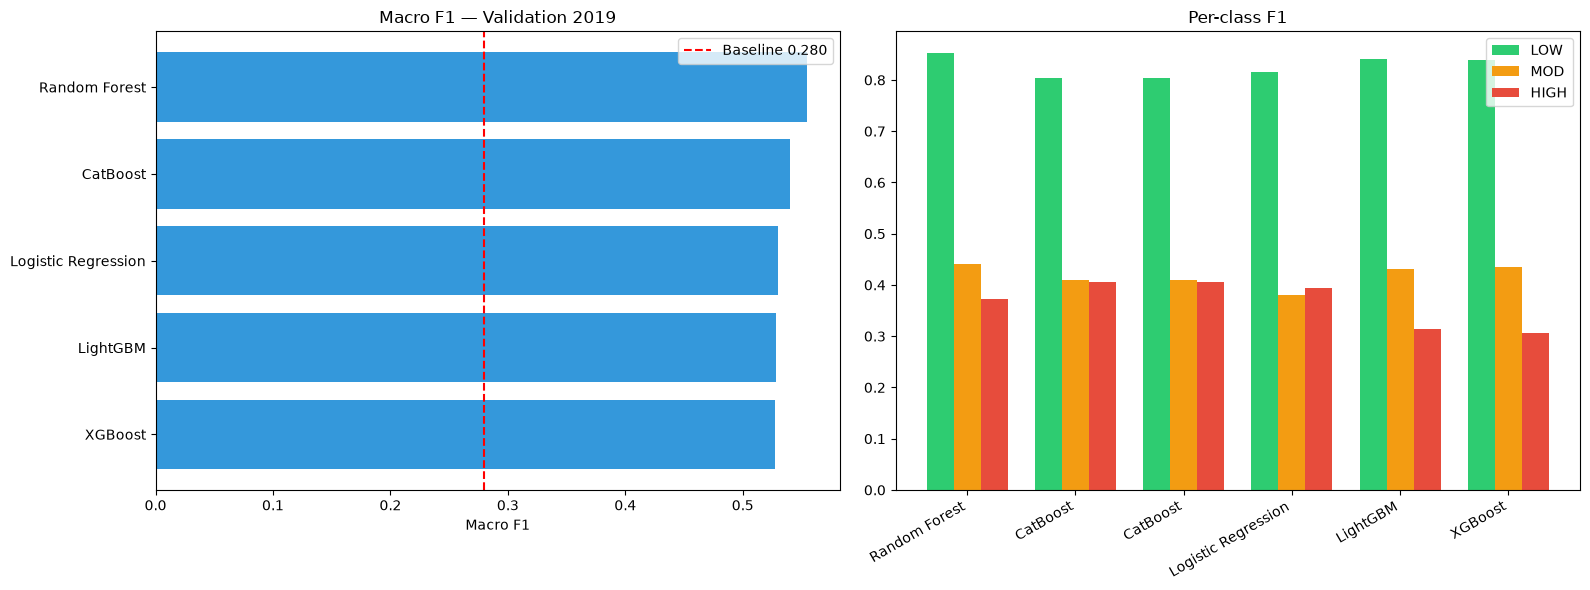

In [27]:
results_df = (pd.DataFrame(results)
              .sort_values("macro_f1", ascending=False)
              .reset_index(drop=True))
 
baseline_f1 = results_df[results_df["model"]=="Majority Baseline"]["macro_f1"].values[0]
 
print("=" * 75)
print("MODEL COMPARISON — VALIDATION (2019)")
print("=" * 75)
print(f"Baseline macro F1: {baseline_f1:.4f}\n")
print(f"{'Rank':<5} {'Model':<22} {'MacroF1':>9} {'BalAcc':>8} {'AUC':>7} "
      f"{'F1-LOW':>8} {'F1-MOD':>8} {'F1-HIGH':>9}")
print("─" * 80)
for i, row in results_df.iterrows():
    marker = " ← WINNER" if i == 0 else ""
    print(f"{i+1:<5} {row['model']:<22} {row['macro_f1']:>9.4f} {row['balanced_acc']:>8.4f} "
          f"{row['auc_ovr']:>7.4f} {row['f1_LOW']:>8.4f} "
          f"{row['f1_MODERATE']:>8.4f} {row['f1_HIGH']:>9.4f}{marker}")
 
print(f"\nBest improvement over baseline: "
      f"+{results_df.iloc[0]['macro_f1']-baseline_f1:.4f} macro F1")
 
# Bar chart
fig, axes = plt.subplots(1,2,figsize=(16,6))
models_plot = results_df[results_df["model"]!="Majority Baseline"]
axes[0].barh(models_plot["model"][::-1], models_plot["macro_f1"][::-1], color="#3498db")
axes[0].axvline(baseline_f1, color="red", linestyle="--", label=f"Baseline {baseline_f1:.3f}")
axes[0].set_xlabel("Macro F1"); axes[0].set_title("Macro F1 — Validation 2019"); axes[0].legend()
 
x = np.arange(len(models_plot))
w = 0.25
for j,(col,label) in enumerate([("f1_LOW","LOW"),("f1_MODERATE","MOD"),("f1_HIGH","HIGH")]):
    axes[1].bar(x+j*w, models_plot[col], w, label=label, color=list(RISK_COLORS.values())[j])
axes[1].set_xticks(x+w); axes[1].set_xticklabels(models_plot["model"], rotation=30, ha="right")
axes[1].set_title("Per-class F1"); axes[1].legend()
plt.tight_layout()
plt.savefig(OUT_DIR/"04_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### Final Test Evaluation — 2021–2025

- Select the winning model **only from the 2019 validation results** based on Macro F1.
- Evaluate the selected model **once** on the unseen 2021–2025 test set to measure true temporal generalization.
- Compare validation and test Macro F1 to assess generalization stability and identify potential temporal drift.
- Generate a confusion matrix for the test set.
- Break down test performance by year to identify years with unusually strong or weak performance.

Winner: Random Forest
Val macro F1: 0.5550

────────────────────────────────────────────────────────────
Random Forest  [TEST 2021-2025]
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

         LOW       0.92      0.84      0.88     57928
    MODERATE       0.31      0.54      0.40      8305
        HIGH       0.37      0.28      0.32      2424

    accuracy                           0.78     68657
   macro avg       0.54      0.55      0.53     68657
weighted avg       0.83      0.78      0.80     68657

Macro F1:         0.5310
Balanced Acc:     0.5511
AUC (OvR macro):  0.8174


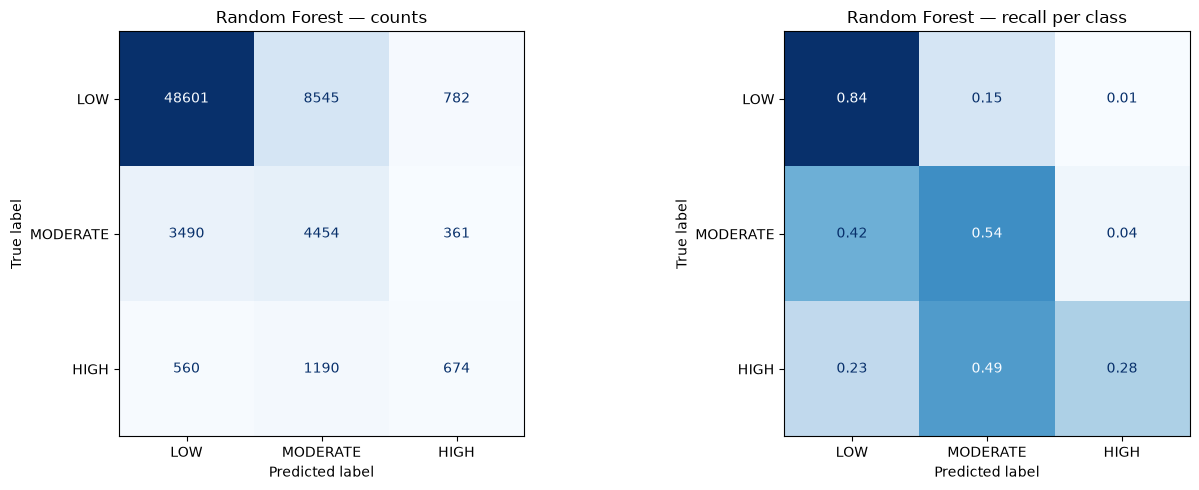


Val → Test gap: +0.0240  (Stable generalisation)

Random Forest — per-year macro F1 on test:
  Year     MacroF1   PosRate        N
  2021      0.5762     19.1%   14,308
  2022      0.5116     18.7%   14,203
  2023      0.5217     14.5%   13,485
  2024      0.4493     10.2%   12,928
  2025      0.4754     15.0%   13,733


In [28]:
winner_name = results_df[results_df["model"]!="Majority Baseline"].iloc[0]["model"]
model_map = {
    "Majority Baseline": baseline,
    "Logistic Regression": lr_pipe,
    "Random Forest": rf,
    "XGBoost": xgb_model,
    "LightGBM": lgb_model,
    "CatBoost": cb_model,
}
winner = model_map[winner_name]
 
print(f"Winner: {winner_name}")
print(f"Val macro F1: {results_df.iloc[0]['macro_f1']:.4f}")
 
# Test evaluation (fill NaN for sklearn models)
X_t = X_test.fillna(0) if not isinstance(winner, CatBoostClassifier) else X_test
test_result = evaluate(winner_name, winner, X_t, y_test, split="TEST 2021-2025")
plot_cm(winner_name, winner, X_t, y_test, "04_cm_test.png")
 
val_f1  = results_df[results_df["model"]==winner_name]["macro_f1"].values[0]
gap     = val_f1 - test_result["macro_f1"]
print(f"\nVal → Test gap: {gap:+.4f}  "
      f"({'Stable generalisation' if abs(gap)<0.05 else 'Drift — check year breakdown'})")
 
# Per-year breakdown on test
print(f"\n{winner_name} — per-year macro F1 on test:")
print(f"  {'Year':<6} {'MacroF1':>9} {'PosRate':>9} {'N':>8}")
for yr in sorted(test["year"].unique()):
    mask = test["year"]==yr
    X_yr = test.loc[mask, FEATURES].fillna(0)
    y_yr = test.loc[mask, TARGET]
    preds = winner.predict(X_yr)
    f1  = f1_score(y_yr, preds, average="macro", zero_division=0)
    pos = 100*(y_yr>0).mean()
    print(f"  {yr:<6} {f1:>9.4f} {pos:>8.1f}% {len(y_yr):>8,}")

### Stress Test — 2020 

- Evaluate the validation-selected winner on the **unseen 2020 stress-test year**.
- 2020 is excluded from model selection and tuning to provide an independent evaluation under unusually severe fire conditions.
- Compare the winner's Macro F1 with its validation performance to assess robustness under extreme conditions.
- Generate a confusion matrix to analyze class-specific errors during the stress year.
- Evaluate all trained models on 2020 for additional performance comparison, without using these results for model selection.


────────────────────────────────────────────────────────────
Random Forest  [STRESS 2020]
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

         LOW       0.85      0.82      0.84     11434
    MODERATE       0.42      0.48      0.44      3716
        HIGH       0.49      0.44      0.46      1845

    accuracy                           0.71     16995
   macro avg       0.58      0.58      0.58     16995
weighted avg       0.72      0.71      0.71     16995

Macro F1:         0.5814
Balanced Acc:     0.5806
AUC (OvR macro):  0.8186


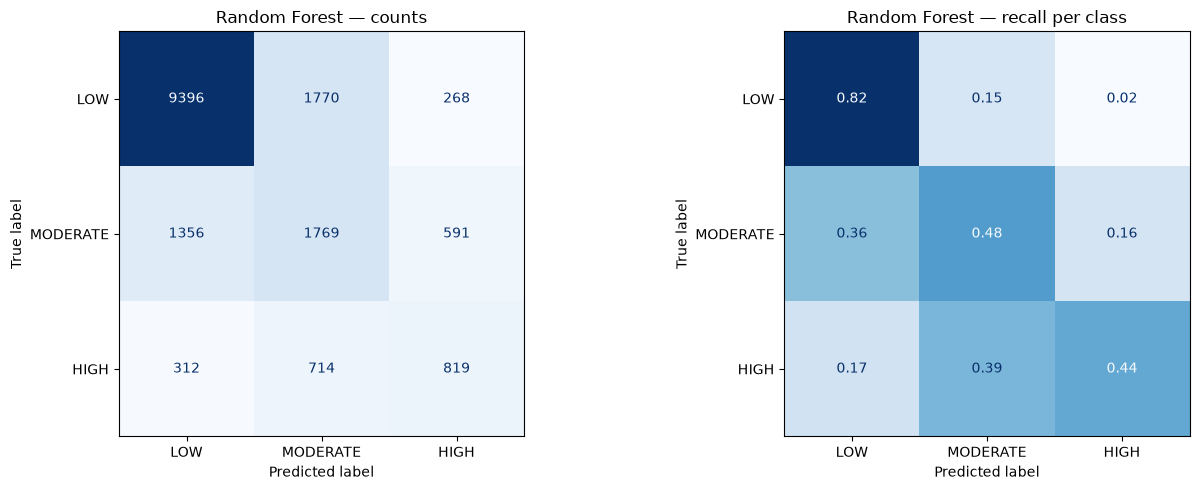

Model holds under extreme 2020 conditions (Δ=-0.0264 vs val)
System reliable during high-severity fire seasons.

All models — stress 2020 macro F1:
  Logistic Regression    0.5349
  Random Forest          0.5814
  XGBoost                0.5565
  LightGBM               0.5553
  CatBoost               0.5455


In [29]:
X_s = X_stress.fillna(0) if not isinstance(winner, CatBoostClassifier) else X_stress
stress_result = evaluate(winner_name, winner, X_s, y_stress, split="STRESS 2020")
plot_cm(winner_name, winner, X_s, y_stress, "04_cm_stress2020.png")
 
gap_stress = val_f1 - stress_result["macro_f1"]
if abs(gap_stress) < 0.05:
    print(f"Model holds under extreme 2020 conditions (Δ={gap_stress:+.4f} vs val)")
    print(f"System reliable during high-severity fire seasons.")
else:
    print(f"Performance drops in extreme 2020 (Δ={gap_stress:+.4f} vs val)")
    print(f"   Consider including 2020 in training for NB05.")
 
# All models on stress test for comparison
print("\nAll models — stress 2020 macro F1:")
for name, model in model_map.items():
    if name == "Majority Baseline": continue
    X_ev = X_stress.fillna(0) if not isinstance(model, CatBoostClassifier) else X_stress
    preds = model.predict(X_ev)
    f1 = f1_score(y_stress, preds, average="macro", zero_division=0)
    print(f"  {name:<22} {f1:.4f}")

### Feature Importance — Winner Model

- Extract and visualize the **top 25 most important features** for the validation-selected winner.

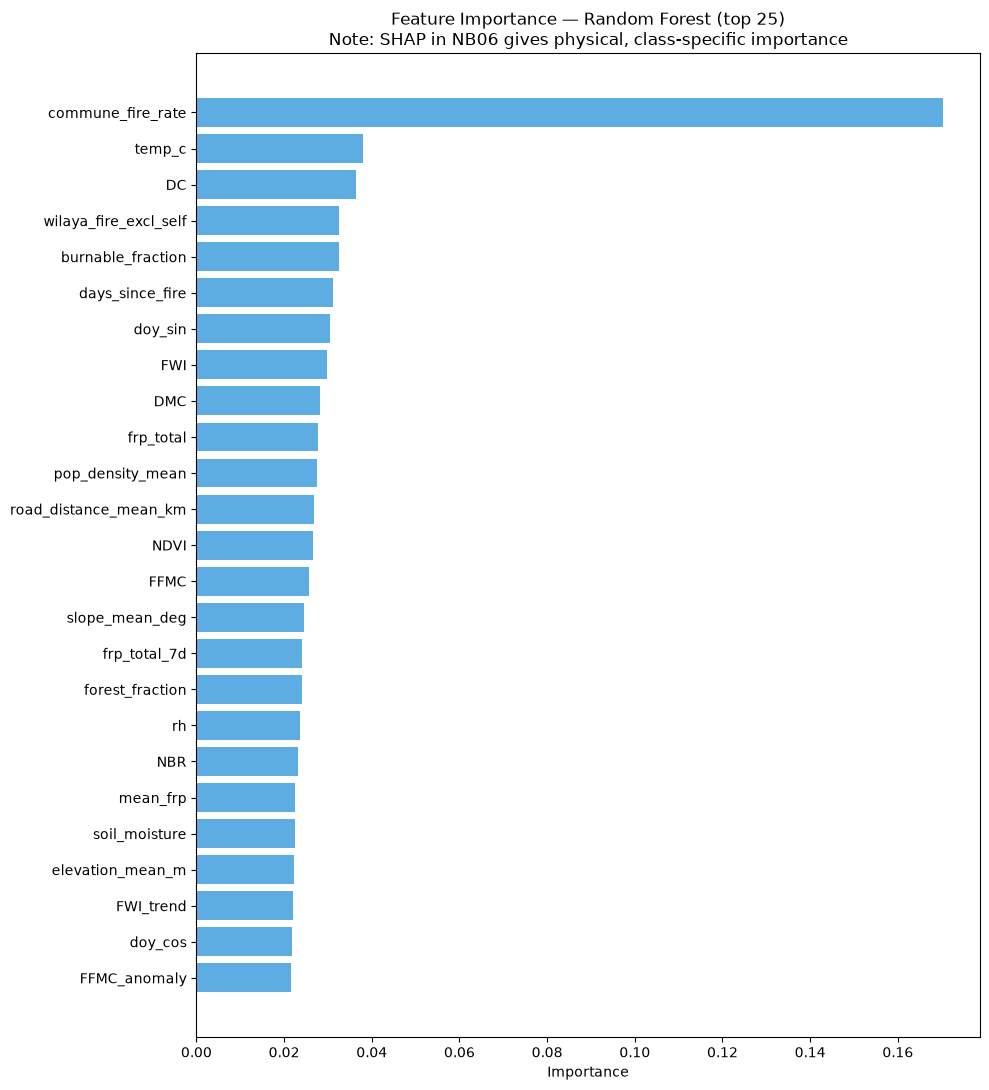


Top 15:
              feature  importance
    commune_fire_rate    0.170231
               temp_c    0.038059
                   DC    0.036348
wilaya_fire_excl_self    0.032602
    burnable_fraction    0.032467
      days_since_fire    0.031103
              doy_sin    0.030567
                  FWI    0.029789
                  DMC    0.028114
            frp_total    0.027811
     pop_density_mean    0.027443
road_distance_mean_km    0.026810
                 NDVI    0.026641
                 FFMC    0.025581
       slope_mean_deg    0.024433


In [30]:
fig, ax = plt.subplots(figsize=(10, 11))
 
if hasattr(winner, "feature_importances_"):
    imp = winner.feature_importances_
elif hasattr(winner, "feature_importance"):
    imp = winner.feature_importance()
elif hasattr(winner, "named_steps"):
    imp = winner.named_steps.get("lr", None)
    imp = imp.coef_.mean(axis=0) if imp is not None else None
else:
    imp = None
 
if imp is not None:
    imp_df = (pd.DataFrame({"feature":FEATURES, "importance":imp})
              .sort_values("importance", ascending=False)
              .head(25))
    ax.barh(imp_df["feature"][::-1], imp_df["importance"][::-1], color="#3498db", alpha=0.8)
    ax.set_title(f"Feature Importance — {winner_name} (top 25)\n"
                 f"Note: SHAP in NB06 gives physical, class-specific importance")
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.savefig(OUT_DIR/"04_feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("\nTop 15:")
    print(imp_df.head(15)[["feature","importance"]].to_string(index=False))

### Save Winner Model and Results

- Save the validation-selected winner as a reusable model file.
- Save metadata containing the model name, selected features, evaluation metrics, and temporal split information.
- Save the complete model comparison results for later analysis and reporting.

In [31]:
joblib.dump(winner, MODEL_Comp_DIR/"winner_model.pkl")
print(f"Saved {winner_name} → winner_model.pkl")
 
winner_meta = {
    "winner_model":    winner_name,
    "features":        FEATURES,
    "val_macro_f1":    float(results_df[results_df["model"]==winner_name]["macro_f1"].values[0]),
    "val_auc_ovr":     float(results_df[results_df["model"]==winner_name]["auc_ovr"].values[0]),
    "test_macro_f1":   test_result["macro_f1"],
    "stress_macro_f1": stress_result["macro_f1"],
    "val_test_gap":    round(gap, 4),
    "train_years":     meta["train_years"],
    "val_years":       meta["validation_years"],
    "test_years":      meta["test_years"],
    "stress_years":    meta["stress_years"],
    "n_features":      len(FEATURES),
}
with open(MODEL_Comp_DIR/"winner_meta.json","w") as f:
    json.dump(winner_meta, f, indent=2)
print("Saved winner_meta.json")
pd.DataFrame(results).to_csv(OUT_DIR/"04_results.csv", index=False)
print("Saved 04_results.csv")

Saved Random Forest → winner_model.pkl
Saved winner_meta.json
Saved 04_results.csv
